# Wafer process suspicion simulation

This notebook runs the wafer-level good/bad vs. context-y scoring simulation and displays the ranked cases visually inline.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from wafer_process_suspicion_sim import (
    DISPLAY_COLUMNS,
    ScoreParams,
    _run_sanity_checks,
    make_simulation_dataframe,
    plot_ranked_cases,
    score_process_dataframe,
)

In [2]:
params = ScoreParams()
sim_df = make_simulation_dataframe()
result_df = score_process_dataframe(sim_df, params=params)
_run_sanity_checks(result_df)

print("Sanity checks passed.")

Sanity checks passed.


In [3]:
result_view = result_df[DISPLAY_COLUMNS].copy()
display(
    result_view.style.format(
        {
            "mean_likelihood": "{:.6g}",
            "quality": "{:.6g}",
            "p_tail": "{:.6g}",
            "evidence": "{:.6g}",
            "r_N": "{:.6g}",
            "score": "{:.6g}",
            "score_exact_alt": "{:.6g}",
        }
    )
)

,process_id,N,n_B,n_G,m,n_B1,n_B0,n_G1,n_G0,mean_likelihood,quality,p_tail,evidence,r_N,score,score_exact_alt
0,lot_perfect_N25,25,5,20,5,5,0,0,20,0.827974,1,1.88218e-05,10.8805,0.757576,8.2428,3.57526
1,noisy_good_in_y1_N25,25,5,20,13,5,0,8,12,0.531322,0.846745,0.0242236,3.72043,0.757576,2.38656,2.60816
2,medium_perfect_N10,10,2,8,2,2,0,0,8,0.827974,1,0.0222222,3.80666,0.555556,2.11481,1.04874
3,bad_missed_N25,25,5,20,1,1,4,0,20,0.516911,0.192264,0.2,1.60944,0.757576,0.234422,2.16845
4,random_mix_N25,25,5,20,6,2,3,4,16,0.46584,0.267178,0.343422,1.0688,0.757576,0.216332,1.68191
5,tiny_perfect_N2,2,1,1,1,1,0,0,1,0.87178,1,0.5,0.693147,0.2,0.138629,0.0548874
6,tiny_single_bad_N1,1,1,0,1,1,0,0,0,0.95,1,1,0,0.111111,0,0.00569925
7,all_y1_N25,25,5,20,25,5,0,20,0,0.27313,0.659754,1,0,0.757576,0,13.8104
8,all_y0_N25,25,5,20,0,0,5,0,20,0.459479,0.127313,1,0,0.757576,0,1.87512
9,no_bad_N25,25,0,25,0,0,0,0,25,0.8,1,1,0,0.757576,0,4.2262


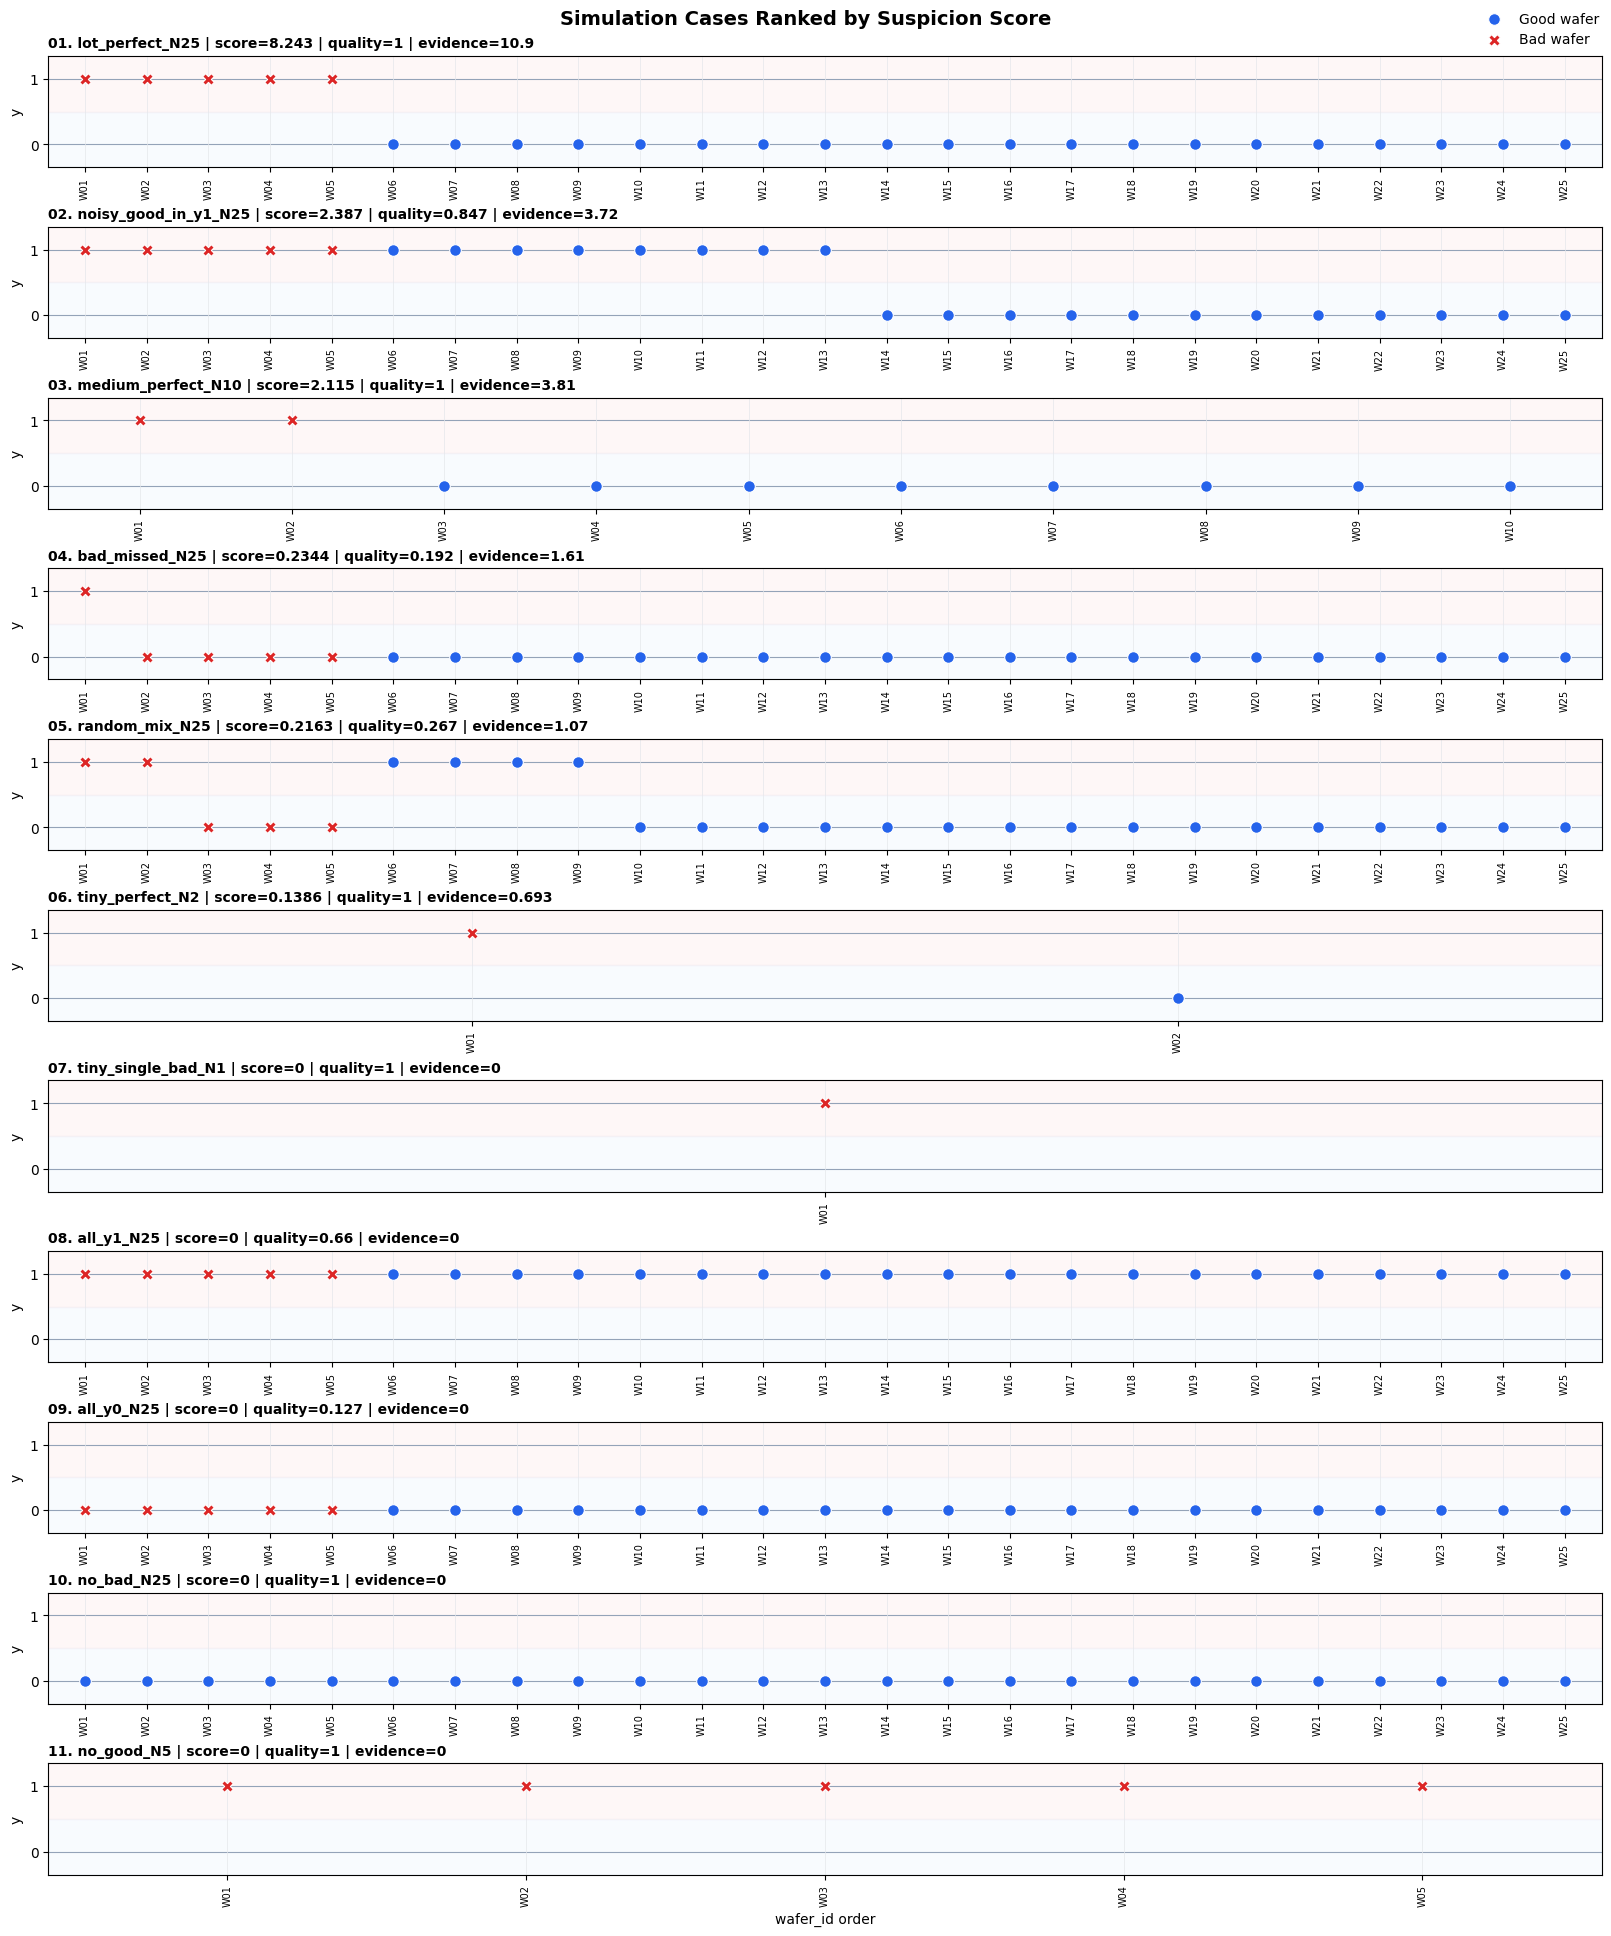

In [4]:
fig = plot_ranked_cases(sim_df, result_df)
plt.show()